In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score  # Added for clustering validation

In [2]:
# Load Iris data
iris = load_iris()
X = iris.data  # features only (unsupervised)
df = pd.DataFrame(X, columns=iris.feature_names)

# Display first 5 rows
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# Elbow Method and Silhouette Analysis
inertia = []
silhouette_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Store inertia
    inertia.append(kmeans.inertia_)

    # Silhouette score is only valid for k >= 2 clusters
    if k > 1:
        score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(score)

In [5]:
# Print the inertia and silhouette values
print("--- Cluster Evaluation Metrics ---")
for i, val in enumerate(inertia, start=1):
    if i == 1:
        print(f"Number of clusters = {i} | Inertia = {val:.2f} | Silhouette Score = N/A (Needs >= 2 clusters)")
    else:
        score = silhouette_scores[i-2]
        print(f"Number of clusters = {i} | Inertia = {val:.2f} | Silhouette Score = {score:.4f}")

--- Cluster Evaluation Metrics ---
Number of clusters = 1 | Inertia = 600.00 | Silhouette Score = N/A (Needs >= 2 clusters)
Number of clusters = 2 | Inertia = 222.36 | Silhouette Score = 0.5818
Number of clusters = 3 | Inertia = 191.02 | Silhouette Score = 0.4799
Number of clusters = 4 | Inertia = 114.35 | Silhouette Score = 0.3850
Number of clusters = 5 | Inertia = 91.05 | Silhouette Score = 0.3450
Number of clusters = 6 | Inertia = 81.55 | Silhouette Score = 0.3339
Number of clusters = 7 | Inertia = 80.78 | Silhouette Score = 0.2664
Number of clusters = 8 | Inertia = 64.43 | Silhouette Score = 0.3416
Number of clusters = 9 | Inertia = 55.71 | Silhouette Score = 0.3244
Number of clusters = 10 | Inertia = 51.12 | Silhouette Score = 0.3354


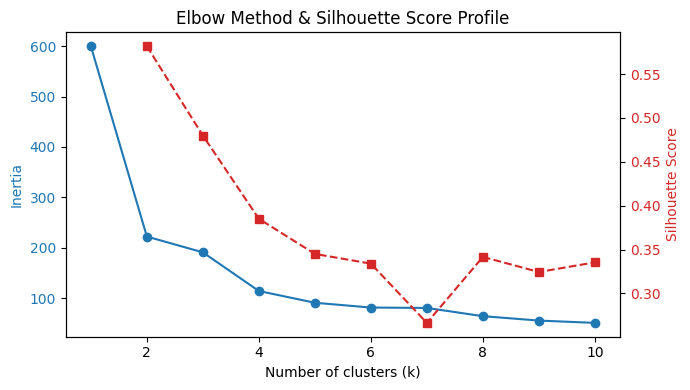

In [6]:
# Create a dual-axis evaluation plot
fig, ax1 = plt.subplots(figsize=(7, 4))

# Plot Inertia on primary y-axis
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color="tab:blue")
ax1.plot(range(1, 11), inertia, marker="o", color="tab:blue", label="Inertia")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Plot Silhouette Score on secondary y-axis
ax2 = ax1.twinx()
ax2.set_ylabel("Silhouette Score", color="tab:red")
ax2.plot(range(2, 11), silhouette_scores, marker="s", color="tab:red", linestyle="--", label="Silhouette Score")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Elbow Method & Silhouette Score Profile")
fig.tight_layout()
plt.show()

In [7]:
# K-Means with 3 clusters (we know Iris has 3 species)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster info to dataframe
df['Cluster'] = clusters
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


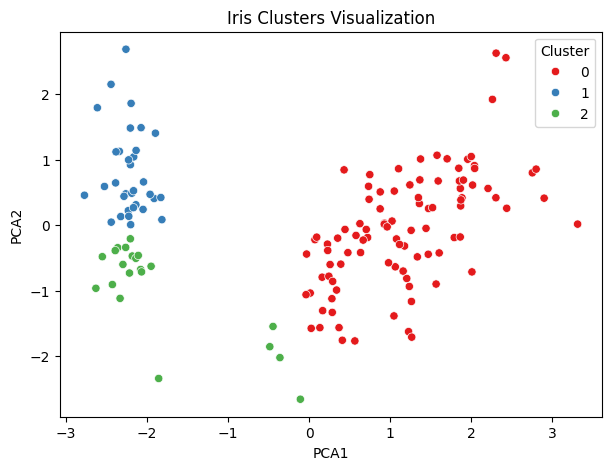

In [8]:
# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

# Plot clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("Iris Clusters Visualization")
plt.show()